# How are in-demand skills trending for Data Analysts?

In [3]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_DA_KE = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Kenya')].copy()

In [5]:
df_DA_KE['job_posted_month'] = df_DA_KE['job_posted_date'].dt.month

In [6]:
df_DA_KE_exploded = df_DA_KE.explode('job_skills')

In [8]:
df_DA_KE_pivot = df_DA_KE_exploded.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)

In [16]:
df_DA_KE_pivot.loc['Total'] = df_DA_KE_pivot.sum() 

df_DA_KE_pivot = df_DA_KE_pivot[df_DA_KE_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_KE_pivot = df_DA_KE_pivot.drop('Total')

df_DA_KE_pivot

job_skills,excel,sql,python,r,tableau,power bi,spss,sas,powerpoint,looker,...,node.js,numpy,matplotlib,kubernetes,microsoft teams,pandas,scikit-learn,ubuntu,tensorflow,terraform
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,43,34,32,29,19,20,17,24,16,2,...,1,0,0,0,0,0,0,1,0,0
2,14,17,17,16,10,3,6,4,4,5,...,0,0,0,0,0,0,0,0,0,0
3,11,10,2,7,4,5,4,2,4,0,...,0,0,0,0,1,0,0,0,0,0
4,10,9,6,7,8,7,3,2,2,1,...,0,1,1,0,0,1,0,0,0,0
5,18,14,15,18,11,7,2,2,2,1,...,0,0,0,0,0,0,0,0,0,0
6,25,26,19,21,21,12,9,4,1,10,...,0,0,0,0,0,0,0,0,0,0
7,25,26,26,27,15,13,5,2,0,4,...,0,0,0,0,0,0,0,0,0,0
8,11,11,10,11,5,7,2,4,4,3,...,0,0,0,0,0,0,0,0,0,0
9,8,7,6,6,4,3,1,0,1,1,...,0,0,0,1,0,0,0,0,0,1


In [41]:
#df_DA_KE_pivot.plot(kind='line')

In [20]:
DA_totals = df_DA_KE.groupby('job_posted_month').size()

In [30]:
df_DA_KE_perc = df_DA_KE_pivot.div(DA_totals/100, 0)

# changes month number to month name
df_DA_KE_perc = df_DA_KE_perc.reset_index()
df_DA_KE_perc['job_posted_month'] = df_DA_KE_perc['job_posted_month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_KE_perc = df_DA_KE_perc.set_index('job_posted_month')

df_DA_KE_perc



job_skills,excel,sql,python,r,tableau,power bi,spss,sas,powerpoint,looker,...,node.js,numpy,matplotlib,kubernetes,microsoft teams,pandas,scikit-learn,ubuntu,tensorflow,terraform
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,36.752137,29.059829,27.350427,24.786325,16.239316,17.094017,14.529915,20.512821,13.675214,1.709402,...,0.854701,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.854701,0.000000,0.000000
Feb,26.415094,32.075472,32.075472,30.188679,18.867925,5.660377,11.320755,7.547170,7.547170,9.433962,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,28.205128,25.641026,5.128205,17.948718,10.256410,12.820513,10.256410,5.128205,10.256410,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.564103,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,28.571429,25.714286,17.142857,20.000000,22.857143,20.000000,8.571429,5.714286,5.714286,2.857143,...,0.000000,2.857143,2.857143,0.000000,0.000000,2.857143,0.000000,0.000000,0.000000,0.000000
May,33.962264,26.415094,28.301887,33.962264,20.754717,13.207547,3.773585,3.773585,3.773585,1.886792,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,37.878788,39.393939,28.787879,31.818182,31.818182,18.181818,13.636364,6.060606,1.515152,15.151515,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,39.682540,41.269841,41.269841,42.857143,23.809524,20.634921,7.936508,3.174603,0.000000,6.349206,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,34.375000,34.375000,31.250000,34.375000,15.625000,21.875000,6.250000,12.500000,12.500000,9.375000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,36.363636,31.818182,27.272727,27.272727,18.181818,13.636364,4.545455,0.000000,4.545455,4.545455,...,0.000000,0.000000,0.000000,4.545455,0.000000,0.000000,0.000000,0.000000,0.000000,4.545455


In [33]:
df_plot = df_DA_KE_perc.iloc[:,:5]

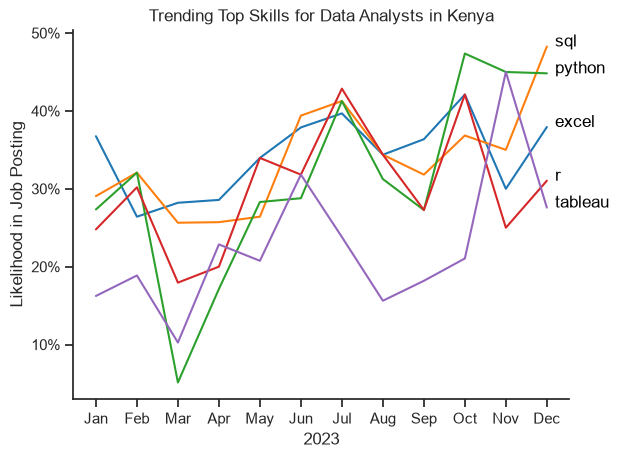

In [40]:
from matplotlib.ticker import PercentFormatter

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
plt.title('Trending Top Skills for Data Analysts in Kenya')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
sns.despine()
plt.legend().remove()

plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')